# Proyecto de aproximación de Apophis en abril de 2029
## Lizeth Serna Santa
### Curso de Mecánica Celeste - Universidad de Antioquia

En este proyecto se aplicarán los conceptos aprendidos en el curso de mecánica celeste alrededor de las temáticas de integración de N-cuerpos y de dos cuerpos.

In [2]:
!pip install -Uq pymcel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 44.3 MB/s eta 0:00:00


In [3]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
import spiceypy as spy


Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [10]:
tabla, jd, X = pc.consulta_horizons(
    id = 'Apophis',
    location = '@SSB',
    epochs = dict(start='2026-04-20',stop='2032-04-20', step ='180d')
)
X = np.array(X)
X

array([[-4.54615645e+10,  1.46498906e+11, -8.91205586e+09,
        -2.72244445e+04, -4.00763765e+03, -4.30333986e+02],
       [ 7.30494894e+09, -1.20742879e+11,  6.59475016e+09,
         3.45068014e+04,  7.26012715e+03,  4.28163844e+02],
       [-1.19047091e+11,  1.10721639e+11, -8.74936147e+09,
        -1.86353812e+04, -1.77744955e+04,  5.08159324e+02],
       [ 9.80036049e+10, -5.38450039e+10,  5.16772868e+09,
         1.81150024e+04,  3.29746582e+04, -1.33181089e+03],
       [-1.57406400e+11,  4.14781172e+10, -5.95425460e+09,
        -5.19153648e+03, -2.52236666e+04,  1.22416011e+03],
       [ 1.05977605e+11,  5.80733685e+10, -6.10196911e+08,
        -1.22722060e+04,  3.28782023e+04, -2.04493952e+03],
       [-1.48602374e+11, -3.98094908e+10, -1.38934227e+09,
         1.10895524e+04, -2.52123119e+04,  1.61169659e+03],
       [ 1.50962142e+11,  8.33129248e+10, -6.19057985e+08,
        -8.52459732e+03,  2.57424134e+04, -1.04695961e+03],
       [-1.45943637e+11,  1.08493998e+11, -6.109

In [8]:
rvec = X[:,:3]
#r = np.linalg.norm(rvec[:], )
vvec = X[:,3:]
#v = np.linalg.norm(vvec)
#Vector de Laplace
mu = pc.constantes.mu_sun #aproximacion
print(len(rvec))
print(len(vvec))


13
13


Determinaciónd de elementos orbitales $(p,e,I,\Omega,\omega,f)$

In [6]:
def calculate_orbital_elements(rvec, vvec, mu):
    """
    Calcula los seis elementos orbitales clásicos a partir de los vectores de posición y velocidad.

    Args:
        rvec (np.ndarray): Vector de posición (x, y, z).
        vvec (np.ndarray): Vector de velocidad (vx, vy, vz).
        mu (float): Parámetro gravitacional estándar del cuerpo central.

    Returns:
        tuple: (p, e, I, Omega, omega, f)
            p (float): Semilatus rectum.
            e (float): Excentricidad.
            I (float): Inclinación (radianes).
            Omega (float): Longitud del nodo ascendente (radianes).
            omega (float): Argumento del periapsis (radianes).
            f (float): Anomalía verdadera (radianes).
    """
    r = np.linalg.norm(rvec)
    v = np.linalg.norm(vvec)

    # Momento angular específico (h)
    hvec = np.cross(rvec, vvec)
    h = np.linalg.norm(hvec)

    # Semilatus rectum (p)
    p = h**2 / mu

    # Vector de excentricidad (evec)
    evec = (np.cross(vvec, hvec) / mu) - (rvec / r)
    e = np.linalg.norm(evec)

    # Inclinación (I)
    I = np.arccos(hvec[2] / h)

    # Vector de nodos (nvec)
    nvec = np.cross([0, 0, 1], hvec) # Nodo ascendente en el plano XY
    n = np.linalg.norm(nvec)

    # Longitud del nodo ascendente (Omega)
    if n == 0:
        Omega = 0.0 # Órbita ecuatorial, Omega no definido, se toma 0
    else:
        Omegap = np.arccos(nvec[0] / n) # Cosine of angle with +X axis
        if nvec[1] >= 0:
            Omega = Omegap
        else:
            Omega = 2 * np.pi - Omegap

    # Argumento del periapsis (omega)
    if e == 0:
        omega = 0.0 # Órbita circular, omega no definido, se toma 0
    elif n == 0:
        omega = np.arccos(evec[0] / e) # Si órbita ecuatorial, se mide desde +X
        if evec[1] < 0: # Check y-component of evec
            omega = 2 * np.pi - omega
    else:
        omegap = np.arccos(np.dot(nvec, evec) / (n * e))
        if evec[2] >= 0: # Check z-component of evec
            omega = omegap
        else:
            omega = 2 * np.pi - omegap

    # Anomalía verdadera (f)
    if e == 0:
        f = np.arccos(np.dot(rvec, evec) / (r * e)) if e != 0 else np.arccos(rvec[0]/r)
        if np.dot(rvec, vvec) < 0:
            f = 2 * np.pi - f
    else:
        fp = np.arccos(np.dot(evec, rvec) / (e * r))
        if np.dot(rvec, vvec) >= 0:
            f = fp
        else:
            f = 2 * np.pi - fp

    return p, e, I, Omega, omega, f

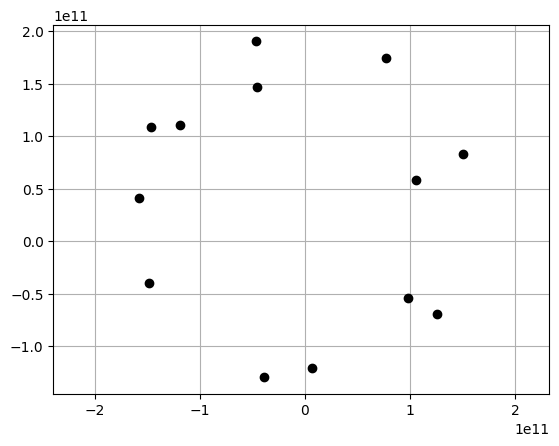

In [11]:
Es = np.zeros((len(jd),6))

for i, jd in enumerate(jd):
  rvec = X[i,:3]
  vvec = X[i, 3:]
  p, e, I, Omega, omega, f = calculate_orbital_elements(rvec, vvec, mu)
  Es[i] = p, e, I, Omega, omega, f

  plt.plot(rvec[0],rvec[1],'ko')

plt.axis('equal')
plt.grid()

Se utiliza `consulta_horizons` de `pymcel` para obtener los parametros fisicos de la Tierra, el Sol y Apophis.
Si Horizons solo entrega el parametro gravitacional $GM$, la masa se calcula con:
$$
M = \frac{GM}{G}
$$
con $G = 6.67430\times 10^{-11}\ \mathrm{m^3\,kg^{-1}\,s^{-2}}$.
Las masas finales se expresan en unidades de masa solar:
$$
M_{\odot} = \frac{M_{\mathrm{kg}}}{M_{\odot,\mathrm{kg}}}
$$
Se verifica la unidad de $GM$ (si esta en $\mathrm{km^3\,s^{-2}}$, se convierte a $\mathrm{m^3\,s^{-2}}$ con un factor $10^9$).

Si la masa no esta disponible en Horizons, se estima con volumen esferico:
$$
M = \frac{4}{3}\pi R^3 \rho
$$
Usamos el diametro $D = 0.34\ \mathrm{km}$ de SBDB (JPL) para Apophis y la densidad de referencia $\rho = 1.5\ \mathrm{g\,cm^{-3}}$ empleada para Apophis en Taylor et al. (2023, PSJ 4 79).
Fuentes:
- JPL SBDB: https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=99942
- Taylor et al. 2023 (PSJ, DOI: 10.3847/PSJ/acccef)

In [ ]:
# Consulta de masas con pymcel
# Valores fisicos en SI
import pymcel.constantes as const

G_SI = const.G  # m^3 kg^-1 s^-2
M_SUN_KG = const.M_sun  # kg

# Horizons requiere una epoca valida
epochs = "2029-04-13 00:00:00"  # UTC para efemerides

def _scalar_from_value(value):
    if hasattr(value, "iloc"):
        return float(value.iloc[0])
    if isinstance(value, (list, tuple, np.ndarray)):
        return float(value[0])
    return float(value)

def _extract_mass_kg(result):
    # Si llega el resultado completo de consulta_horizons
    if isinstance(result, tuple) and len(result) == 3:
        result = result[2]

    # DataFrame de pandas
    if hasattr(result, "columns"):
        for key in ("MASS", "mass", "Mass", "M", "GM", "gm", "GMS", "GM_SI"):
            if key in result.columns:
                value = _scalar_from_value(result[key])
                if key.upper().startswith("GM"):
                    value = value * 1.0e9  # (km^3/s^2) -> (m^3/s^2)
                    return value / G_SI
                return value

    # Estructuras tipo dict
    for key in ("MASS", "mass", "Mass", "M"):
        if hasattr(result, "__contains__") and key in result:
            return _scalar_from_value(result[key])
    for key in ("GM", "gm", "GMS", "GM_SI"):
        if hasattr(result, "__contains__") and key in result:
            gm_value = _scalar_from_value(result[key])
            gm_value_m3_s2 = gm_value * 1.0e9  # (km^3/s^2) -> (m^3/s^2)
            return gm_value_m3_s2 / G_SI
    return None

def _describe_result(label, result):
    print(f"\n{label} -> type: {type(result)}")
    if hasattr(result, "columns"):
        print("columns:", list(result.columns))
    elif hasattr(result, "keys"):
        try:
            print("keys:", list(result.keys()))
        except Exception:
            pass

def _require_mass(label, mass_kg):
    if mass_kg is None:
        print(f"Advertencia: no se encontro masa/GM para {label}.")
        return np.nan
    return mass_kg

# Masas de Sol y Tierra desde constantes de pymcel (SI)
M_sun_kg = const.M_sun  # kg
M_earth_kg = const.M_earth  # kg

# Apophis: intentar Horizons
try:
    tabla_ap, ts_ap, salida_ap = pc.consulta_horizons(
        "99942",
        epochs=epochs,
        datos="ephemeris",
        propiedades="default",
    )
    _describe_result("Apophis", salida_ap)
    M_apophis_kg = _require_mass("Apophis", _extract_mass_kg(salida_ap))  # kg
except Exception as exc:
    print(f"Error al consultar Horizons para Apophis: {exc}")
    M_apophis_kg = np.nan

# Fallback: masa estimada con diametro y densidad de referencia
if np.isnan(M_apophis_kg):
    D_APOPHIS_KM = 0.34  # km (JPL SBDB)
    R_APOPHIS_M = D_APOPHIS_KM * 1.0e3 / 2.0  # m
    RHO_APOPHIS = 1.5e3  # kg/m^3 (Taylor et al. 2023, PSJ 4 79)
    M_apophis_kg = (4.0 / 3.0) * np.pi * (R_APOPHIS_M ** 3) * RHO_APOPHIS  # kg
    print("Usando masa estimada para Apophis (diametro + densidad de referencia).")

# Conversion a unidades de masa solar (Msun)
M_sun = M_sun_kg / M_SUN_KG  # Msun
M_earth = M_earth_kg / M_SUN_KG  # Msun
M_apophis = M_apophis_kg / M_SUN_KG  # Msun

print("Masas en Msun:")
print(f"  Sol: {M_sun:.6e} Msun")
print(f"  Tierra: {M_earth:.6e} Msun")
print(f"  Apophis: {M_apophis:.6e} Msun")


Error al consultar Horizons para Apophis: 'HorizonsClass' object has no attribute 'ephemeris'
Usando masa estimada para Apophis (diametro + densidad de referencia).
Masas en Msun:
  Sol: 1.000000e+00 Msun
  Tierra: 3.003489e-06 Msun
  Apophis: 1.552461e-20 Msun
